# Multivariate Assumptions: Dispersion and Pre-Analysis Checks

## Overview

Before running PERMANOVA, dbRDA, or other multivariate tests, several properties of the data and the dissimilarity matrix need to be checked. Skipping these leads to misinterpretation — particularly confusing differences in **location** (community composition) with differences in **dispersion** (community variability).

| Check | Tool | What It Tests |
|---|---|---|
| Homogeneity of multivariate dispersion | `vegan::betadisper()` | Whether groups have equal spread around their centroid — the multivariate analog of Levene's test |
| Dissimilarity matrix inspection | `vegan::vegdist()` | Whether chosen distance metric is appropriate for the data |
| Species/variable distribution | Histograms, transformations | Whether raw data needs transformation before computing distances |
| Multivariate outliers | Distance-to-centroid plots | Whether any samples are extreme outliers driving results |

> **Why this matters:**  
> PERMANOVA is sensitive to differences in dispersion between groups. If Group A has more variable community composition than Group B, PERMANOVA may return a significant result even when the group centroids are identical. `betadisper()` partitions this so you know what you're detecting.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Are disturbed sites more variable in community composition than reference sites, independent of any centroid shift? |
| **Healthcare** | Is the microbiome more variable in disease patients than in healthy controls? |
| **Finance** | Are portfolio compositions more heterogeneous in one market segment vs. another? |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)        # betadisper(), vegdist(), adonis2()
library(ggordiplots)  # ggplot2-based ordination plots (optional)

set.seed(42)

# ── Simulate community composition data ──────────────────────────────────────
# 3 habitat types, 15 sites each, 20 species
n_sites   <- 45
n_species <- 20

habitat <- rep(c("reference", "degraded", "restored"), each = 15)

# Reference: low variation around a stable composition
# Degraded: different composition AND higher variation
# Restored: intermediate composition, intermediate variation
sim_community <- function(n, mean_vec, sd_vec) {
  t(replicate(n, {
    counts <- round(exp(rnorm(n_species, log(mean_vec + 0.1), sd_vec)))
    pmax(counts, 0)
  }))
}

ref_means  <- c(8,7,6,5,5,4,3,3,2,2,1,1,1,1,1,0,0,0,0,0)
deg_means  <- c(1,1,2,2,3,5,6,7,8,8,5,4,3,2,1,1,1,1,0,0)
rest_means <- c(5,5,4,4,4,4,3,3,2,2,2,2,1,1,1,1,0,0,0,0)

comm_mat <- rbind(
  sim_community(15, ref_means,  rep(0.3, n_species)),
  sim_community(15, deg_means,  rep(0.9, n_species)),  # higher dispersion
  sim_community(15, rest_means, rep(0.5, n_species))
)
rownames(comm_mat) <- paste0("site", 1:n_sites)
colnames(comm_mat) <- paste0("sp",   1:n_species)

env_data <- tibble(
  site    = paste0("site", 1:n_sites),
  habitat = habitat
)

cat(sprintf("Community matrix: %d sites × %d species\n",
            nrow(comm_mat), ncol(comm_mat)))
cat(sprintf("Habitat groups: %s\n",
            paste(table(habitat), names(table(habitat)), sep = " ", collapse = ", ")))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute

Warning message:
"package 'ggor

Community matrix: 45 sites × 20 species
Habitat groups: 15 degraded, 15 reference, 15 restored


---

## Step 1: Data Transformation

Raw abundance data often needs transformation before computing dissimilarities, depending on the research question and the distribution of counts.

Warning message in decostand(x, "max", 2, na.rm = na.rm):
"result contains NaN, perhaps due to impossible mathematical
                 operation
"
Warning message in decostand(x, "total", 1, na.rm = na.rm):
"result contains NaN, perhaps due to impossible mathematical
                 operation
"
Warning message in scale_x_log10():
"log-10 transformation introduced infinite values."
Warning message:
"Removed 183 rows containing non-finite outside the scale range (`stat_bin()`)."


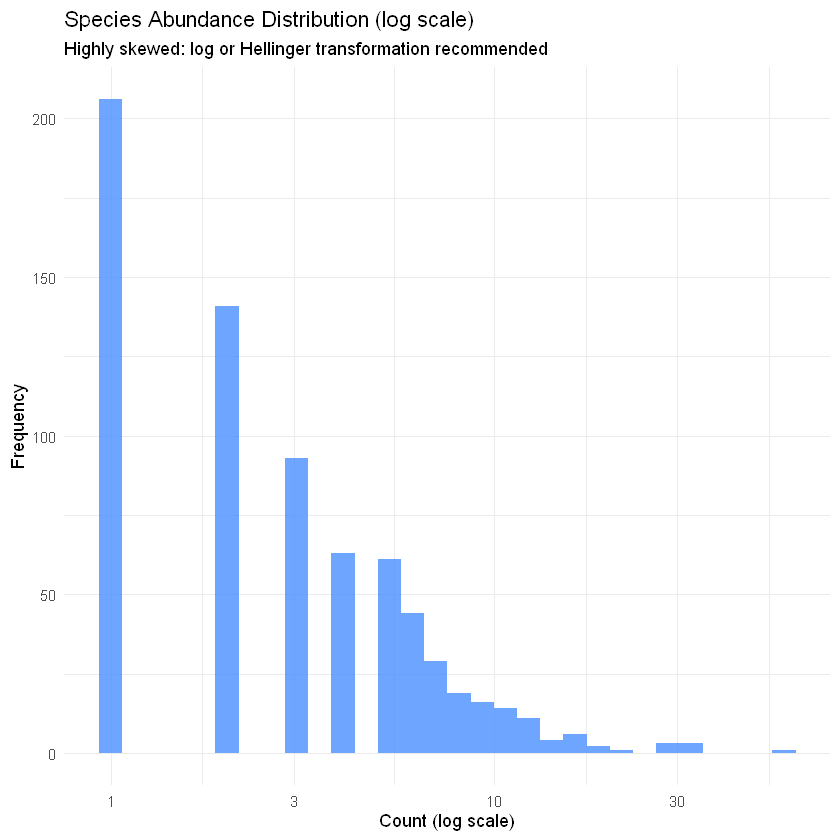

In [2]:
# ── Common transformations for community data ─────────────────────────────────
# Hellinger: square root of relative abundance — recommended for most Euclidean-based methods
comm_hell <- vegan::decostand(comm_mat, method = "hellinger")

# Wisconsin double standardization: standardize by species max then site total
comm_wisc <- vegan::wisconsin(comm_mat)

# Presence/absence: collapses to 0/1
comm_pa   <- vegan::decostand(comm_mat, method = "pa")

# log(x+1): reduces influence of very abundant species
comm_log  <- log1p(comm_mat)

# ── When to use each ──────────────────────────────────────────────────────────
# Hellinger:    general purpose; recommended before PCA on community data (Legendre & Gallagher 2001)
# Wisconsin:    emphasizes rare species; good for NMDS
# P/A:          when abundance is unreliable or you only care about presence
# log(x+1):     moderate down-weighting of dominants; common for Bray-Curtis
# None (raw):   only appropriate with Bray-Curtis on standardized counts

# ── Inspect species abundance distribution ────────────────────────────────────
as.data.frame(comm_mat) %>%
  pivot_longer(everything(), names_to = "species", values_to = "count") %>%
  ggplot(aes(x = count)) +
  geom_histogram(bins = 30, fill = "#4a8fff", alpha = 0.8) +
  scale_x_log10() +
  labs(title = "Species Abundance Distribution (log scale)",
       subtitle = "Highly skewed: log or Hellinger transformation recommended",
       x = "Count (log scale)", y = "Frequency") +
  theme_minimal()

---

## Step 2: Choose a Dissimilarity Metric

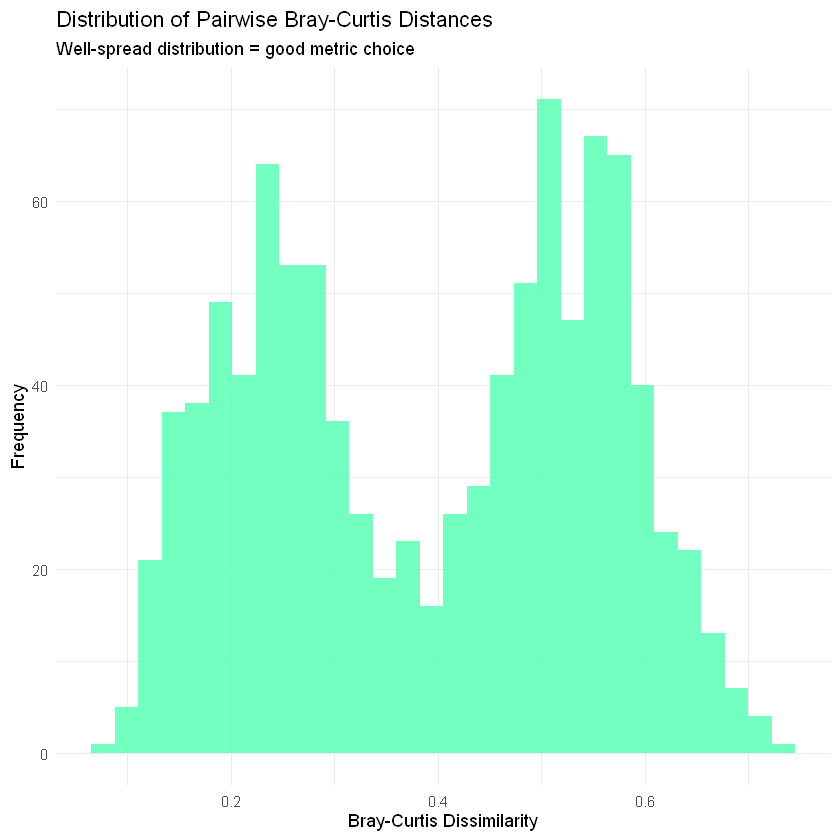

In [3]:
# ── Common dissimilarity metrics via vegan::vegdist() ────────────────────────
dist_bray    <- vegan::vegdist(comm_mat,  method = "bray")      # Bray-Curtis
dist_jaccard <- vegan::vegdist(comm_pa,   method = "jaccard")   # Jaccard (P/A)
dist_hell    <- vegan::vegdist(comm_hell, method = "euclidean") # Hellinger-Euclidean

# ── When to use each ──────────────────────────────────────────────────────────
# Bray-Curtis:          most common for abundance data; accounts for shared absences
# Jaccard:              presence/absence data; emphasizes species turnover
# Sørensen:             P/A; similar to Jaccard, slightly different formula
# Hellinger-Euclidean:  after Hellinger transformation; good for gradient analysis
# Unifrac (phyloseq):   phylogenetically-weighted; microbiome data

# ── Visualize: distance distribution ─────────────────────────────────────────
tibble(bray = as.vector(dist_bray)) %>%
  ggplot(aes(x = bray)) +
  geom_histogram(bins = 30, fill = "#4fffb0", alpha = 0.8) +
  labs(title = "Distribution of Pairwise Bray-Curtis Distances",
       subtitle = "Well-spread distribution = good metric choice",
       x = "Bray-Curtis Dissimilarity", y = "Frequency") +
  theme_minimal()

---

## Step 3: Test Homogeneity of Dispersion — `betadisper()`

This is the essential pre-PERMANOVA check. If dispersion differs between groups, a significant PERMANOVA may reflect dispersion differences rather than centroid differences.


	Homogeneity of multivariate dispersions

Call: vegan::betadisper(d = dist_bray, group = env_data$habitat)

No. of Positive Eigenvalues: 25
No. of Negative Eigenvalues: 19

Average distance to median:
 degraded reference  restored 
   0.3041    0.1097    0.1749 

Eigenvalues for PCoA axes:
(Showing 8 of 44 eigenvalues)
 PCoA1  PCoA2  PCoA3  PCoA4  PCoA5  PCoA6  PCoA7  PCoA8 
1.8309 0.3968 0.3401 0.2763 0.2583 0.2205 0.2031 0.1467 



Permutation test for homogeneity of multivariate dispersions
Permutation: free
Number of permutations: 999

Response: Distances
          Df  Sum Sq  Mean Sq      F N.Perm Pr(>F)    
Groups     2 0.29388 0.146942 46.307    999  0.001 ***
Residuals 42 0.13327 0.003173                         
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = distances ~ group, data = df)

$group
                         diff         lwr         upr     p adj
reference-degraded -0.1944626 -0.24443529 -0.14448992 0.0000000
restored-degraded  -0.1292723 -0.17924499 -0.07929962 0.0000005
restored-reference  0.0651903  0.01521761  0.11516299 0.0078582


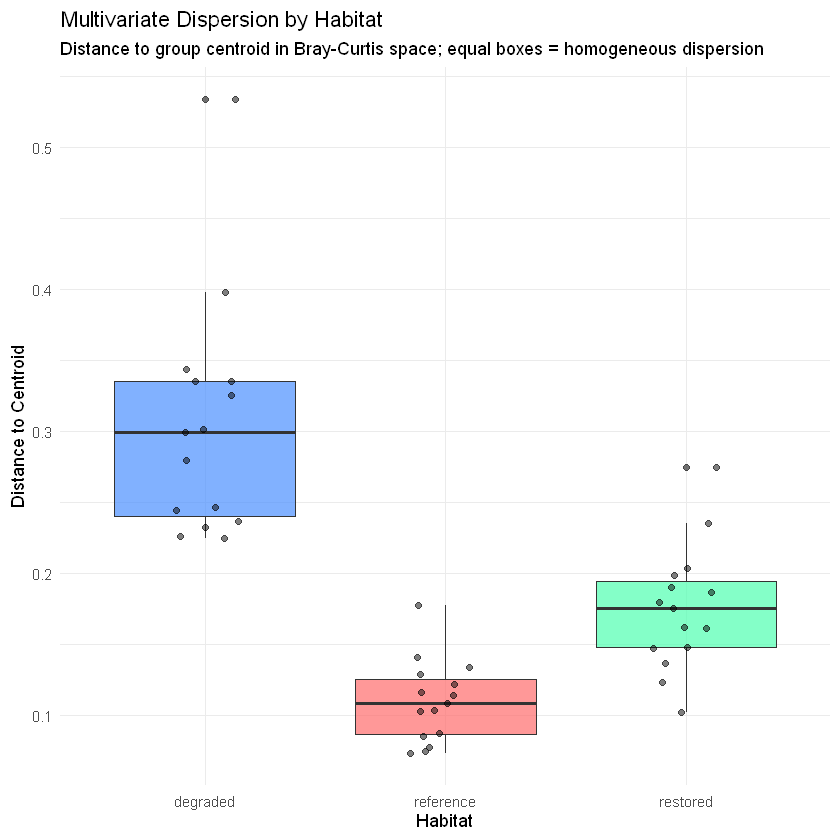

In [4]:
# ── betadisper: homogeneity of multivariate dispersion ───────────────────────
bd <- vegan::betadisper(
  dist_bray,
  group = env_data$habitat
)
print(bd)

# ── Test significance ─────────────────────────────────────────────────────────
permutest(bd, permutations = 999)
# H0: all groups have equal multivariate dispersion
# p < 0.05: dispersion differs between groups
# → Interpret PERMANOVA results with caution; significant result may reflect
#   dispersion differences, not just centroid shifts

# ── Pairwise comparison of dispersions ───────────────────────────────────────
TukeyHSD(bd)
# Which specific pairs of groups differ in dispersion?

# ── Plot: distances to group centroid ─────────────────────────────────────────
tibble(
  site    = env_data$site,
  habitat = env_data$habitat,
  dist_to_centroid = bd$distances
) %>%
  ggplot(aes(x = habitat, y = dist_to_centroid, fill = habitat)) +
  geom_boxplot(alpha = 0.7) +
  geom_jitter(width = 0.15, alpha = 0.5, size = 1.5) +
  scale_fill_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  labs(title = "Multivariate Dispersion by Habitat",
       subtitle = "Distance to group centroid in Bray-Curtis space; equal boxes = homogeneous dispersion",
       x = "Habitat", y = "Distance to Centroid") +
  theme_minimal() + theme(legend.position = "none")

---

## Step 4: Visualize Group Spread with PCoA

A quick PCoA (principal coordinates analysis) visualizes how groups cluster and how spread out they are — a visual complement to the betadisper test.

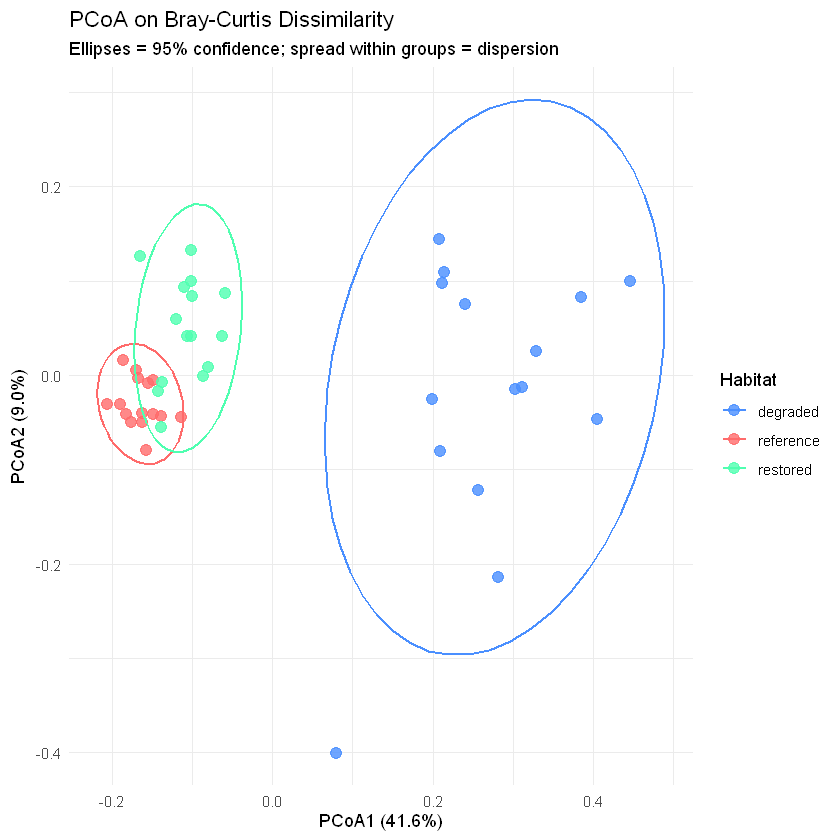

In [5]:
# ── PCoA on Bray-Curtis distances ─────────────────────────────────────────────
pcoa_result <- cmdscale(dist_bray, k = 2, eig = TRUE)

pcoa_df <- tibble(
  site    = env_data$site,
  habitat = env_data$habitat,
  PCoA1   = pcoa_result$points[, 1],
  PCoA2   = pcoa_result$points[, 2]
)

# Variance explained by each axis
pct_explained <- round(pcoa_result$eig / sum(pcoa_result$eig[pcoa_result$eig > 0]) * 100, 1)

ggplot(pcoa_df, aes(x = PCoA1, y = PCoA2, color = habitat)) +
  geom_point(size = 3, alpha = 0.8) +
  stat_ellipse(level = 0.95, linewidth = 0.8) +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  labs(title = "PCoA on Bray-Curtis Dissimilarity",
       subtitle = "Ellipses = 95% confidence; spread within groups = dispersion",
       x = sprintf("PCoA1 (%.1f%%)", pct_explained[1]),
       y = sprintf("PCoA2 (%.1f%%)", pct_explained[2]),
       color = "Habitat") +
  theme_minimal()

# Note: degraded sites should show larger ellipses (higher dispersion)

---

## Common Pitfalls

**1. Running PERMANOVA without checking dispersion first**  
PERMANOVA is sensitive to both centroid differences and dispersion differences. A significant result could mean group centroids differ, or that one group has more variable composition. Always run `betadisper()` first and report both results.

**2. Choosing a distance metric without justification**  
Bray-Curtis is appropriate for abundance data; Jaccard for presence/absence. Using Euclidean distance on raw species counts is almost never appropriate for community data — it gives too much weight to abundant species and is affected by double-zeros.

**3. Forgetting to transform before computing distances**  
Highly dominant species can overwhelm Bray-Curtis distances if abundances span several orders of magnitude. Consider log(x+1) or Hellinger transformation before distance computation.

**4. Ignoring multivariate outliers**  
A single outlier site with a very unusual species composition can inflate dispersion estimates and influence ordinations. Examine the distance-to-centroid plot for extreme values.

**5. Not reporting which transformation and distance metric were used**  
Results are not reproducible without this information. Always state: data transformation (if any), dissimilarity metric, and number of permutations.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*